# Quantum Phase Estimation

This notebook demonstrates the QPE algorithm from Chapter 7, Quantum Phase Estimation, with with 2 control qubits and 1 target qubit.

This is the most basic demo of the QPE circuit. 
The circuit is hard-coded for the number of control qubits.
With 2 control qubits, the QPE circuit is only able to resolve the eigenvalue phase to $\frac{1}{4}$ fractions:

| Eigenvalue ($\lambda$) | Phase ($\phi$) | Qubit state   |
| ---------------------: | -------------: | ------------: |
|                     +1 |              0 | $\|00\rangle$ |
|                     -1 |  $\frac{1}{2}$ | $\|10\rangle$ |
|                    $i$ |  $\frac{1}{4}$ | $\|01\rangle$ |
|                   $-i$ |  $\frac{3}{4}$ | $\|11\rangle$ |

[![Open In Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Polaris-QCI/Quantum-Algorithms-and-Applications/main?labpath=Qiskit%2F07-Quantum-Phase-Estimation%2Fqpe-2control-1target.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Polaris-QCI/Quantum-Algorithms-and-Applications/blob/main/Qiskit/07-Quantum-Phase-Estimation/qpe-2control-1target.ipynb)

## 0. Setup

The cells below install the packages and import the libraries needed by this demo.

In [5]:
# Imports

import math
import numpy as np
import sympy as sp
from IPython.display import display, Markdown
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.quantum_info import partial_trace, Statevector
from qiskit.visualization import plot_histogram

Common single-qubit operators:

In [18]:
𝜋 = math.pi

X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
S = np.array([[1, 0], [0, 1j]])
T = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]])
def RX(θ):
    return np.array([[np.cos(θ / 2), -1j * np.sin(θ / 2)], [-1j * np.sin(θ / 2), np.cos(θ / 2)]])
def RY(θ):
    return np.array([[np.cos(θ / 2), -np.sin(θ / 2)], [np.sin(θ / 2), np.cos(θ / 2)]])
def RZ(θ):
    return np.array([[np.exp(-1j *θ / 2), 0], [0, np.exp(1j * θ / 2)]])

# 1. Circuit Definition

The following cell implements a QPE circuit with 2 control qubits and 1 target qubit. 
The operator $U$ and eigenstate $|\psi\rangle$ are provided as arguments.

In [7]:
def make_qpe_circuit(U, psi) -> QuantumCircuit:
    U1 = UnitaryGate(U, label="$U$")
    U2 = UnitaryGate(np.linalg.matrix_power(U, 2), label="$U^2$")

    qc = QuantumCircuit(3, 2)
    # 𝚿₁ is qubits 0, 1 in superposition; qubit 2 initialised with eigenstate u
    qc.h(0)
    qc.h(1)
    qc.initialize(psi, 2)
    qc.save_statevector(label="Ψ₁")
    # 𝚿₂ is with the controlled operations applied
    qc.append(U1.control(1), [0, 2])
    qc.append(U2.control(1), [1, 2])
    qc.save_statevector(label="Ψ₂")
    # 𝚿₃ is with IQFT applied to the control qubits
    iqft = QFTGate(2).inverse()
    iqft.label = "$\\text{QFT}^{\\dagger}$"
    qc.append(iqft, [0, 1])
    qc.save_statevector(label="Ψ₃")
    
    # Measure the control qubits into the classical register
    qc.measure([0, 1], [0, 1])

    return qc


def latex_vec(v):
    return sp.latex(sp.Matrix([[sp.nsimplify(x)] for x in v.flatten()]))


def show_circuit(U, ev, show_circuit=False, show_counts=False, show_histogram=False, show_result=True) -> None:
    _, evs = np.linalg.eig(U)
    psi = evs[ev-1]
    
    qc = make_qpe_circuit(U, psi)

    backend = AerSimulator(method="statevector")
    tqc = transpile(qc, backend)

    job = backend.run(tqc, shots=1024)
    result = job.result()

    𝚿3 = result.data(0)["Ψ₃"]
    𝜑 = partial_trace(𝚿3, [2]).to_statevector().draw('latex_source')
    counts = result.get_counts(0)

    if show_circuit:
        display(qc.draw("mpl"))
    if show_counts:
        print(f"Counts: {counts}")
    if show_histogram:
        display(plot_histogram(counts, title="Measurement Results"))
    if show_result:
        display(Markdown(f"Result for $u_{{{ev}}}$ = ${latex_vec(psi)}$: $|\\phi\\rangle ={𝜑}$"))                     


The next cell shows the circuit diagram.

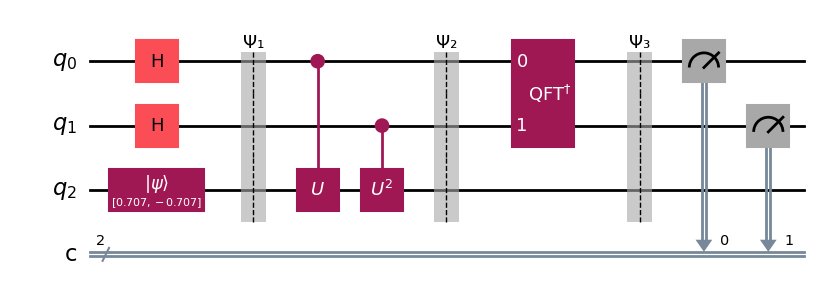

In [12]:
show_circuit(X, 1, show_circuit=True, show_result=False)

# 2. Results for Pauli matrices

The Pauli matrices $X$, $Y$ and $Z$ all have eigenvalues -1 and +1.

The next cell runs the QPE circuit for each eigenvector of each Pauli matrix, and confirms these eignevalues.

In [9]:
display(Markdown("## X"))
show_circuit(X, 1)
show_circuit(X, 2)
display(Markdown("## Y"))
show_circuit(Y, 1)
show_circuit(Y, 2)
display(Markdown("## Z"))
show_circuit(Z, 1)
show_circuit(Z, 2)

## X

Result for $u_{1}$ = $\left[\begin{matrix}\frac{\sqrt{2}}{2}\\- \frac{\sqrt{2}}{2}\end{matrix}\right]$: $|\phi\rangle = |10\rangle$

Result for $u_{2}$ = $\left[\begin{matrix}\frac{\sqrt{2}}{2}\\\frac{\sqrt{2}}{2}\end{matrix}\right]$: $|\phi\rangle = |00\rangle$

## Y

Result for $u_{1}$ = $\left[\begin{matrix}- \frac{\sqrt{2} i}{2}\\\frac{\sqrt{2}}{2}\end{matrix}\right]$: $|\phi\rangle = |00\rangle$

Result for $u_{2}$ = $\left[\begin{matrix}\frac{\sqrt{2}}{2}\\- \frac{\sqrt{2} i}{2}\end{matrix}\right]$: $|\phi\rangle = |10\rangle$

## Z

Result for $u_{1}$ = $\left[\begin{matrix}1\\0\end{matrix}\right]$: $|\phi\rangle = |00\rangle$

Result for $u_{2}$ = $\left[\begin{matrix}0\\1\end{matrix}\right]$: $|\phi\rangle = |10\rangle$

# 3. Results for $S$ operator

The unitary operator
$$
S = \begin{pmatrix}
1 & 0 \\
0 & i
\end{pmatrix}
$$

has eigenvalues 1 and $i$, which are shown in phase form as $|00\rangle$ and $|01\rangle$ respectively.

The next cell verifies this.

In [10]:
display(Markdown("## S"))
show_circuit(S, 1)
show_circuit(S, 2)

## S

Result for $u_{1}$ = $\left[\begin{matrix}1\\0\end{matrix}\right]$: $|\phi\rangle = |00\rangle$

Result for $u_{2}$ = $\left[\begin{matrix}0\\1\end{matrix}\right]$: $|\phi\rangle = |01\rangle$

# 4. Results for RX, RY, RZ Rotation Gates

For the rotation gates $R_X(\theta)$, $R_Y(\theta)$ and $R_Z(\theta)$ have eigenvalues $e^{i\theta/2}$ and $e^{-i\theta/2}$.

With two qubits of precision, we can confirm these exactly for $\theta\in\{0, \pi, 2\pi\}$:

In [24]:
display(Markdown("## RX(0)"))
show_circuit(RX(0), 1)
show_circuit(RX(0), 2)
display(Markdown("## RX(𝜋)"))
show_circuit(RX(𝜋), 1)
show_circuit(RX(𝜋), 2)
# the next one generates "QiskitError: 'Sum of amplitudes-squared is not 1, but 0.7813992350550185'". I think it is because of numerical imprecision.
# display(Markdown("## RX(2𝜋)"))
# show_circuit(RX(2 * 𝜋), 1)
# show_circuit(RX(2 * 𝜋), 2)

display(Markdown("## RY(0)"))
show_circuit(RY(0), 1)
show_circuit(RY(0), 2)
# The next one generates "QiskitError: 'Density matrix is not a pure state'". I think it is because of numerical imprecision.
# display(Markdown("## RY(𝜋)"))
# show_circuit(RY(𝜋), 1)
# show_circuit(RY(𝜋), 2)
display(Markdown("## RY(2𝜋)"))
show_circuit(RY(2 * 𝜋), 1)
show_circuit(RY(2 * 𝜋), 2)

display(Markdown("## RZ(0)"))
show_circuit(RZ(0), 1)
show_circuit(RZ(0), 2)
display(Markdown("## RZ(𝜋)"))
show_circuit(RZ(𝜋), 1)
show_circuit(RZ(𝜋), 2)
display(Markdown("## RZ(2𝜋)"))
show_circuit(RZ(2 * 𝜋), 1)
show_circuit(RZ(2 * 𝜋), 2)

## RX(0)

Result for $u_{1}$ = $\left[\begin{matrix}1\\0\end{matrix}\right]$: $|\phi\rangle = |00\rangle$

Result for $u_{2}$ = $\left[\begin{matrix}0\\1\end{matrix}\right]$: $|\phi\rangle = |00\rangle$

## RX(𝜋)

Result for $u_{1}$ = $\left[\begin{matrix}\frac{\sqrt{2}}{2}\\\frac{\sqrt{2}}{2}\end{matrix}\right]$: $|\phi\rangle = |11\rangle$

...

Result for $u_{1}$ = $\left[\begin{matrix}1\\0\end{matrix}\right]$: $|\phi\rangle = |11\rangle$

Result for $u_{2}$ = $\left[\begin{matrix}0\\1\end{matrix}\right]$: $|\phi\rangle = |01\rangle$

## RZ(2𝜋)

Result for $u_{1}$ = $\left[\begin{matrix}1\\0\end{matrix}\right]$: $|\phi\rangle = |10\rangle$

Result for $u_{2}$ = $\left[\begin{matrix}0\\1\end{matrix}\right]$: $|\phi\rangle = |10\rangle$

# 5. Unified Rotation Gate

From QC&I 5.2.6 we have the general single-qubit rotation gate:

$$
R_u(\gamma,\theta,\phi) = 
\begin{pmatrix}
\cos\frac{\gamma}{2}-i\sin\frac{\gamma}{2}\cos\theta & -i\sin\frac{\gamma}{2}\sin\theta e^{-i\phi} \\
-i\sin\frac{\gamma}{2}\sin\theta e^{i\phi} & \cos\frac{\gamma}{2}+i\sin\frac{\gamma}{2}\cos\theta
\end{pmatrix}
$$

which has eigenvalues $e^{-i\gamma/2}$ and $e^{i\gamma/2}$.

With two qubits of precision, we can confirm these exactly for $\gamma\in\{0, \pi, 2\pi, 3\pi\}$:

In [35]:
def Ru(𝛾, 𝜃, 𝜑):
    return np.array([
        [np.cos(𝛾 / 2) - 1j * np.sin(𝛾 / 2) * np.cos(𝜃), -1j * np.sin(𝛾 / 2) * np.sin(𝜃) * np.exp(-1j * 𝜑)],
         [-1j * np.sin(𝛾 / 2) * np.sin(𝜃) * np.exp(1j * 𝜑), np.cos(𝛾 / 2) + 1j * np.sin(𝛾 / 2) * np.cos(𝜃)]
    ])

display(Markdown("## Ru(0, 0, 0)"))
show_circuit(Ru(0 * 𝜋, 0, 0), 1)
show_circuit(Ru(0 * 𝜋, 0, 0), 2)

display(Markdown("## Ru(𝜋, 0, 0)"))
show_circuit(Ru(1 * 𝜋, 0, 0), 1)
show_circuit(Ru(1 * 𝜋, 0, 0), 2)

display(Markdown("## Ru(2𝜋, 0, 0)"))
show_circuit(Ru(2 * 𝜋, 0, 0), 1)
show_circuit(Ru(2 * 𝜋, 0, 0), 2)

display(Markdown("## Ru(3𝜋, 0, 0)"))
show_circuit(Ru(3 * 𝜋, 0, 0), 1)
show_circuit(Ru(3 * 𝜋, 0, 0), 2)

## Ru(0, 0, 0)

Result for $u_{1}$ = $\left[\begin{matrix}1\\0\end{matrix}\right]$: $|\phi\rangle = |00\rangle$

Result for $u_{2}$ = $\left[\begin{matrix}0\\1\end{matrix}\right]$: $|\phi\rangle = |00\rangle$

## Ru(𝜋, 0, 0)

Result for $u_{1}$ = $\left[\begin{matrix}1\\0\end{matrix}\right]$: $|\phi\rangle = |11\rangle$

...

Result for $u_{1}$ = $\left[\begin{matrix}1\\0\end{matrix}\right]$: $|\phi\rangle = |10\rangle$

Result for $u_{2}$ = $\left[\begin{matrix}0\\1\end{matrix}\right]$: $|\phi\rangle = |10\rangle$

## Ru(3𝜋, 0, 0)

Result for $u_{1}$ = $\left[\begin{matrix}1\\0\end{matrix}\right]$: $|\phi\rangle = |01\rangle$

Result for $u_{2}$ = $\left[\begin{matrix}0\\1\end{matrix}\right]$: $|\phi\rangle = |11\rangle$